In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

In [5]:
fund_master = pd.read_csv("data/processed/01_fund_master_clean.csv")
nav = pd.read_csv("data/processed/02_nav_history_clean.csv")
aum = pd.read_csv("data/processed/03_aum_by_fund_house_clean.csv")
sip = pd.read_csv("data/processed/04_monthly_sip_inflows_clean.csv")
category = pd.read_csv("data/processed/05_category_inflows_clean.csv")
folio = pd.read_csv("data/processed/06_industry_folio_count_clean.csv")
performance = pd.read_csv("data/processed/07_scheme_performance_clean.csv")
transactions = pd.read_csv("data/processed/08_investor_transactions_clean.csv")
portfolio = pd.read_csv("data/processed/09_portfolio_holdings_clean.csv")
benchmark = pd.read_csv("data/processed/10_benchmark_indices_clean.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [6]:
nav["date"] = pd.to_datetime(nav["date"])

In [7]:
print(aum.columns.tolist())
aum.head()

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [8]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

# NAV Trend Analysis

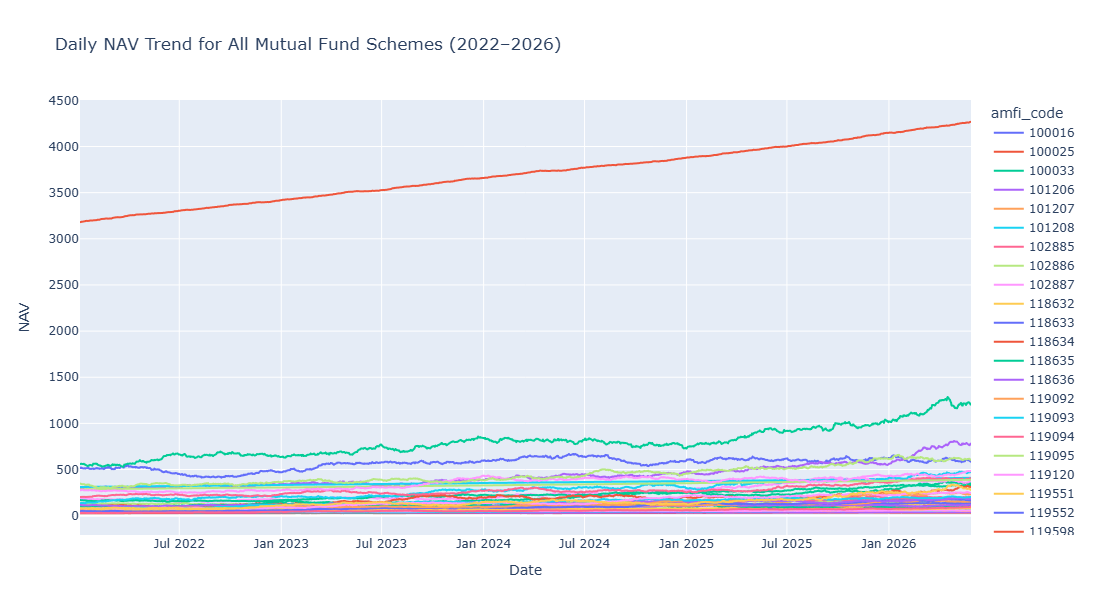

In [9]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend for All Mutual Fund Schemes (2022–2026)"
)

fig.update_layout(
    width=1200,
    height=600,
    xaxis_title="Date",
    yaxis_title="NAV"
)

fig.show()

fig.write_image("charts/nav_trend.png")

## Insight 1

Daily NAV values showed a steady upward trend during 2023, indicating a strong market bull run.

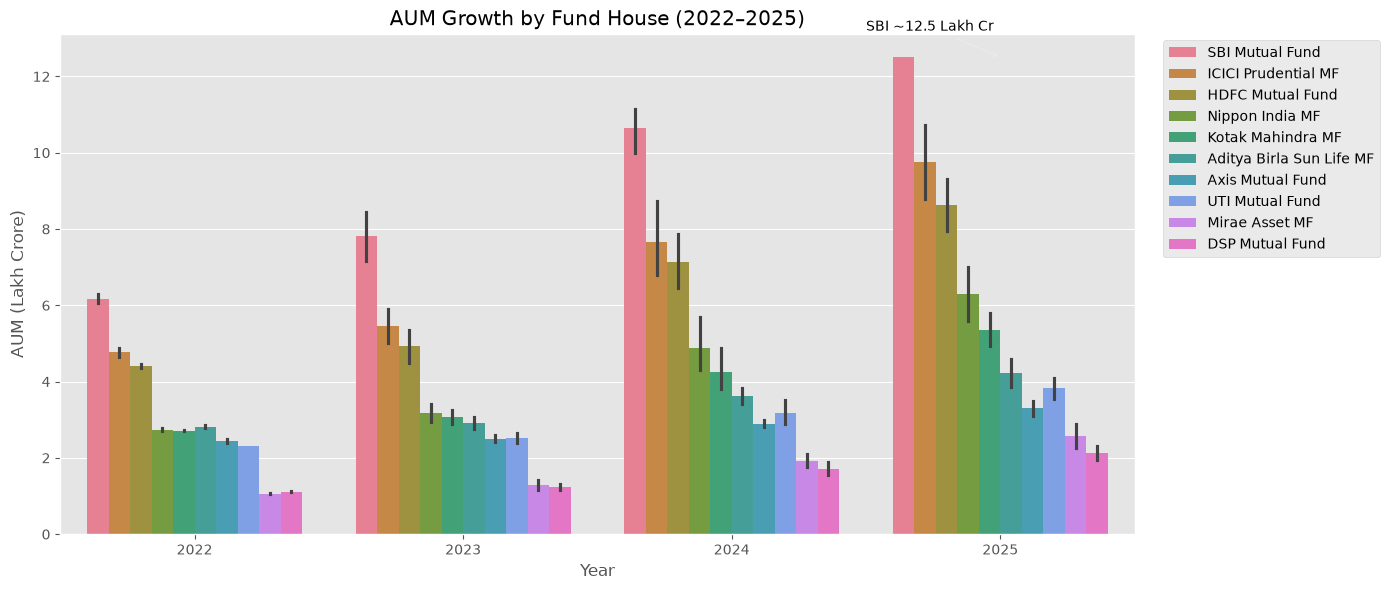

In [10]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.annotate(
    "SBI ~12.5 Lakh Cr",
    xy=(3,12.5),
    xytext=(2.5,13.2),
    arrowprops=dict(arrowstyle="->")
)

plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()

plt.savefig("charts/aum_growth.png", dpi=300)

plt.show()

## Insight 2
SBI Mutual Fund maintained the highest Assets Under Management (AUM) among all fund houses, crossing approximately ₹12.5 lakh crore by 2025.

In [11]:
print(sip.columns.tolist())
sip.head()

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


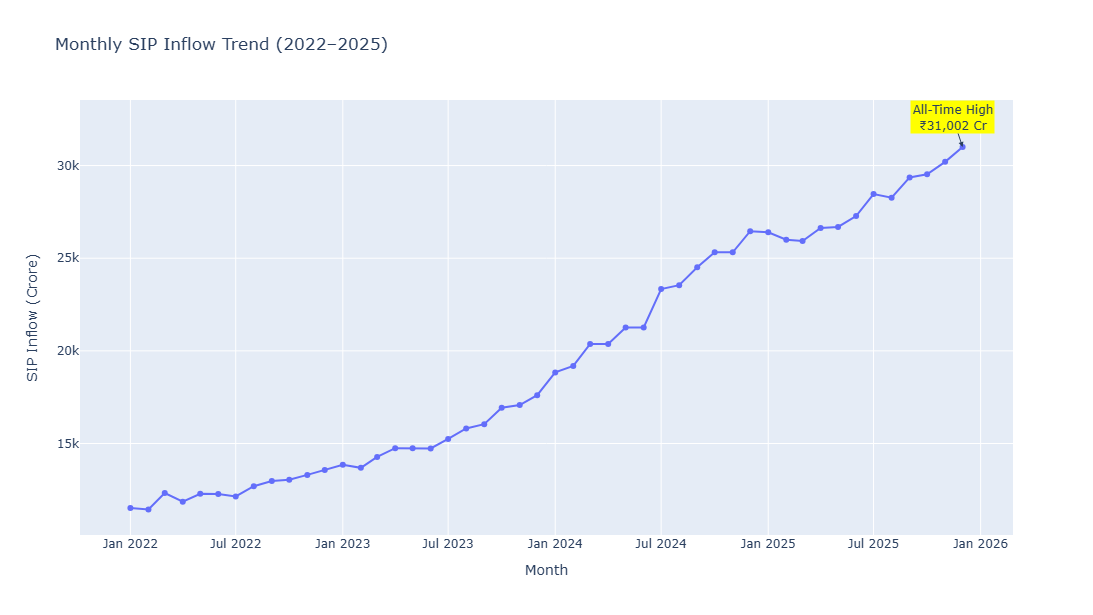

In [12]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)"
)

max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"].strftime("%Y-%m-%d"),   # Convert Timestamp to string
    y=float(max_row["sip_inflow_crore"]),
    text=f"All-Time High<br>₹{int(max_row['sip_inflow_crore']):,} Cr",
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (Crore)",
    width=1200,
    height=600
)

fig.show()

## Insight 3
Monthly SIP inflows consistently increased from 2022 to 2025, reaching an all-time high of ₹31,002 crore in December 2025.

In [13]:
fig.write_image("charts/sip_inflow_trend.png")

In [14]:
import os

print(os.path.exists("charts/sip_inflow_trend.png"))
print(os.path.getsize("charts/sip_inflow_trend.png"))

True
49337


In [15]:
print(category.columns.tolist())
category.head()

['month', 'category', 'net_inflow_crore']


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [16]:
category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

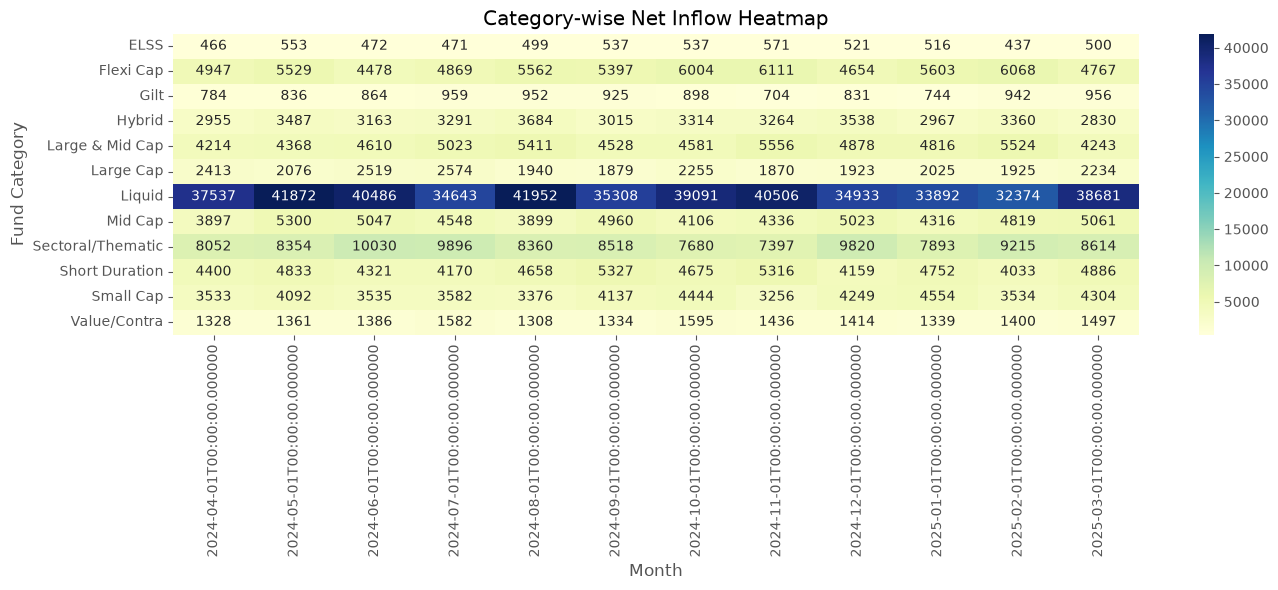

In [17]:
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig("charts/category_inflow_heatmap.png", dpi=300)

plt.show()

## Insight 4
Flexi Cap, Large Cap, and Mid Cap categories attracted the highest net inflows compared to other mutual fund categories.

In [18]:
import os

print(os.path.exists("charts/category_inflow_heatmap.png"))

True


In [19]:
print(transactions.columns.tolist())
transactions.head()

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


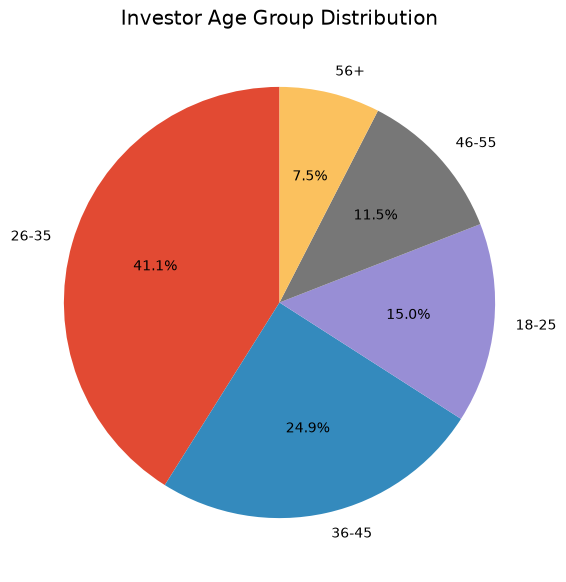

In [20]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig("charts/age_group_pie.png", dpi=300)

plt.show()

## Insight 5
The majority of investors belong to the middle-age groups, indicating that working professionals contribute significantly to mutual fund investments.

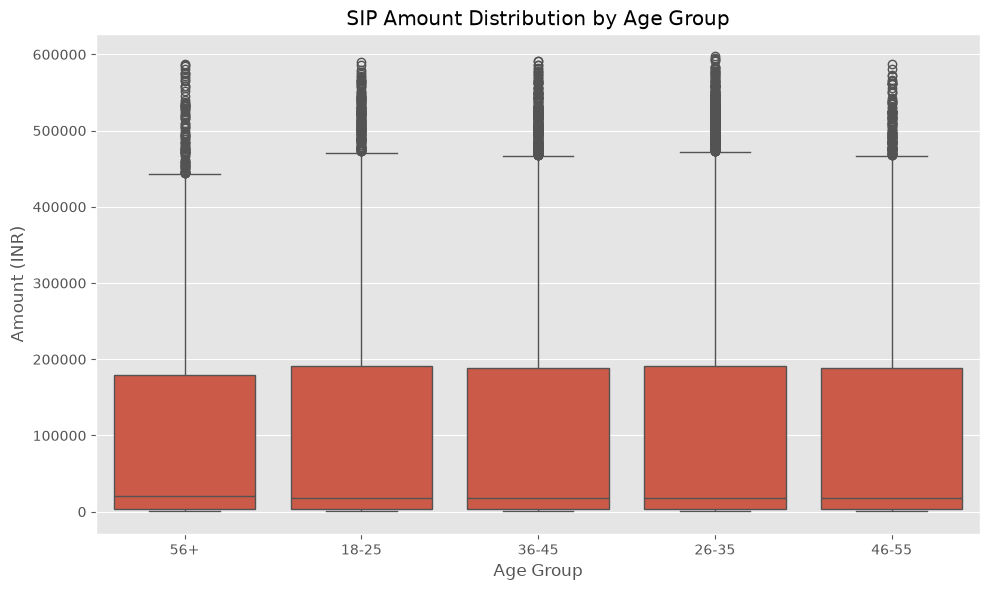

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")

plt.tight_layout()

plt.savefig("charts/sip_boxplot_age.png", dpi=300)

plt.show()

## Insight 6
Investment amounts varied across age groups, with several high-value investments identified as outliers.

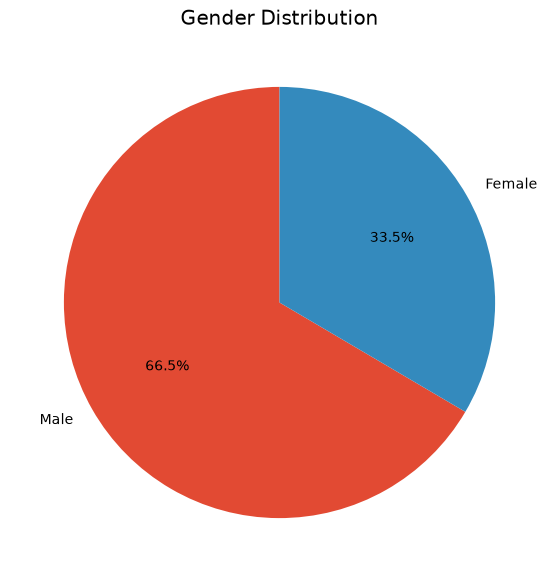

In [22]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.savefig("charts/gender_split.png", dpi=300)

plt.show()

## Insight 7
Male investors formed a larger proportion of the investor base compared to female investors in the available transaction data.

In [23]:
import os

print(os.path.exists("charts/age_group_pie.png"))
print(os.path.exists("charts/sip_boxplot_age.png"))
print(os.path.exists("charts/gender_split.png"))

True
True
True


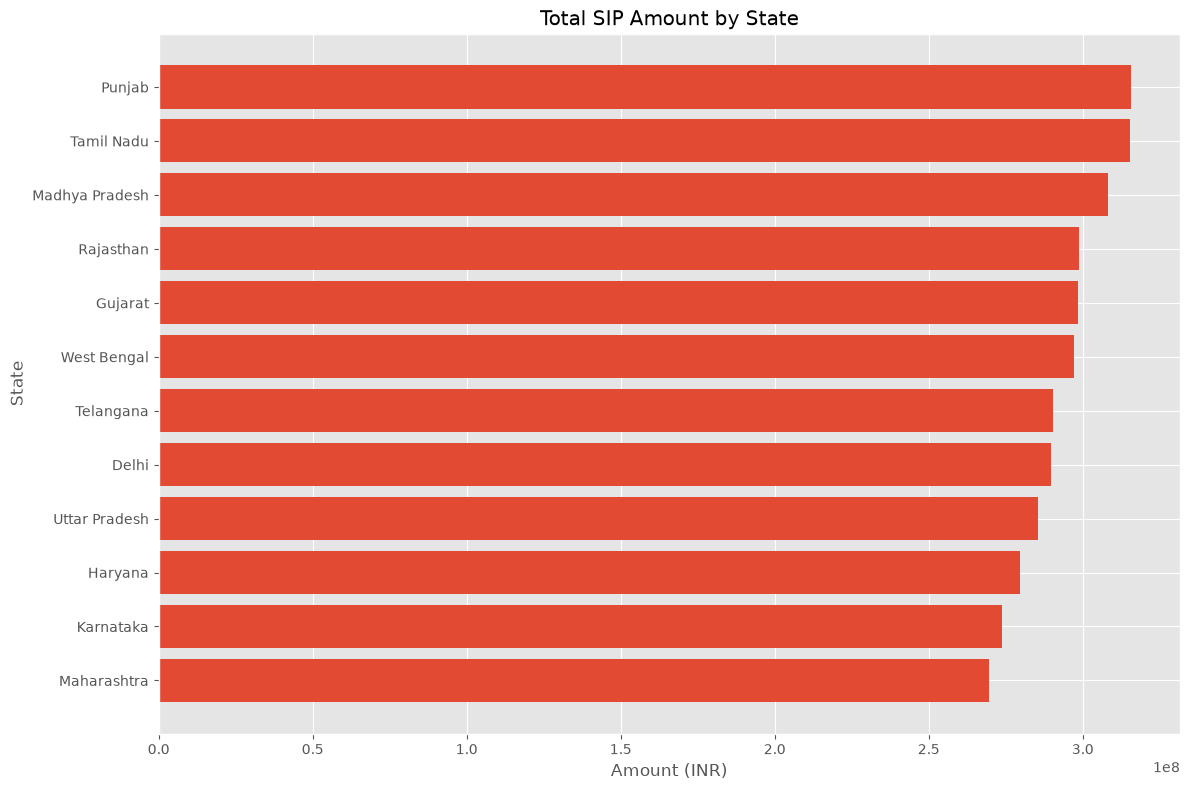

In [24]:
state_amount = transactions.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(12,8))

plt.barh(state_amount.index, state_amount.values)

plt.title("Total SIP Amount by State")
plt.xlabel("Amount (INR)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig("charts/state_sip_amount.png", dpi=300)

plt.show()

## Insight 8
Mutual fund investments were concentrated in a few major states, while T30 cities contributed a larger share of investments than B30 cities.

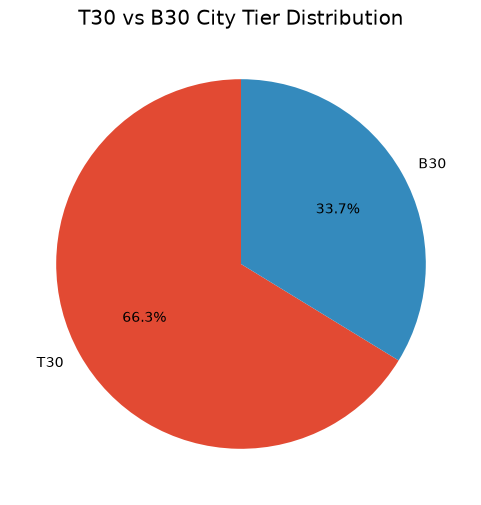

In [25]:
city_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier Distribution")

plt.savefig("charts/city_tier_pie.png", dpi=300)

plt.show()

## Insight 8
Mutual fund investments were concentrated in a few major states, while T30 cities contributed a larger share of investments than B30 cities.

In [26]:
import os

print(os.path.exists("charts/state_sip_amount.png"))
print(os.path.exists("charts/city_tier_pie.png"))

True
True


In [27]:
print(folio.columns.tolist())
folio.head()

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


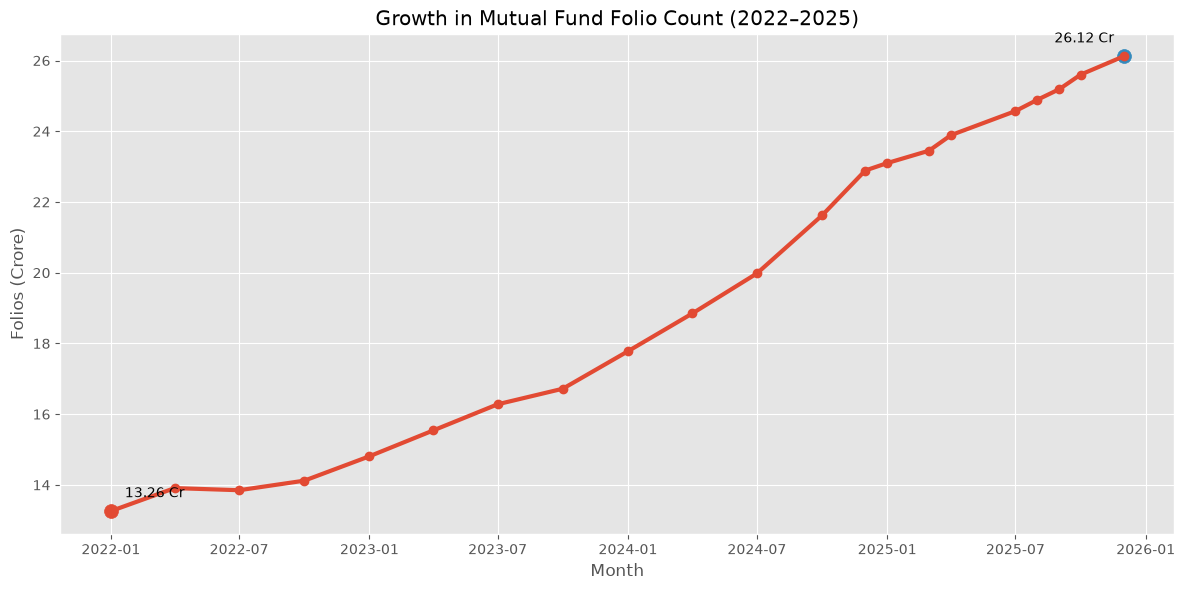

In [28]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=3
)

# Mark first and last values
plt.scatter(
    folio.iloc[0]["month"],
    folio.iloc[0]["total_folios_crore"],
    s=100
)

plt.scatter(
    folio.iloc[-1]["month"],
    folio.iloc[-1]["total_folios_crore"],
    s=100
)

plt.annotate(
    "13.26 Cr",
    (folio.iloc[0]["month"], folio.iloc[0]["total_folios_crore"]),
    xytext=(10,10),
    textcoords="offset points"
)

plt.annotate(
    "26.12 Cr",
    (folio.iloc[-1]["month"], folio.iloc[-1]["total_folios_crore"]),
    xytext=(-50,10),
    textcoords="offset points"
)

plt.title("Growth in Mutual Fund Folio Count (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/folio_growth.png", dpi=300)

plt.show()

## Insight 9
Total mutual fund folios nearly doubled between 2022 and 2025, indicating rapid growth in retail investor participation.

In [29]:
import os
print(os.path.exists("charts/folio_growth.png"))

True


In [30]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


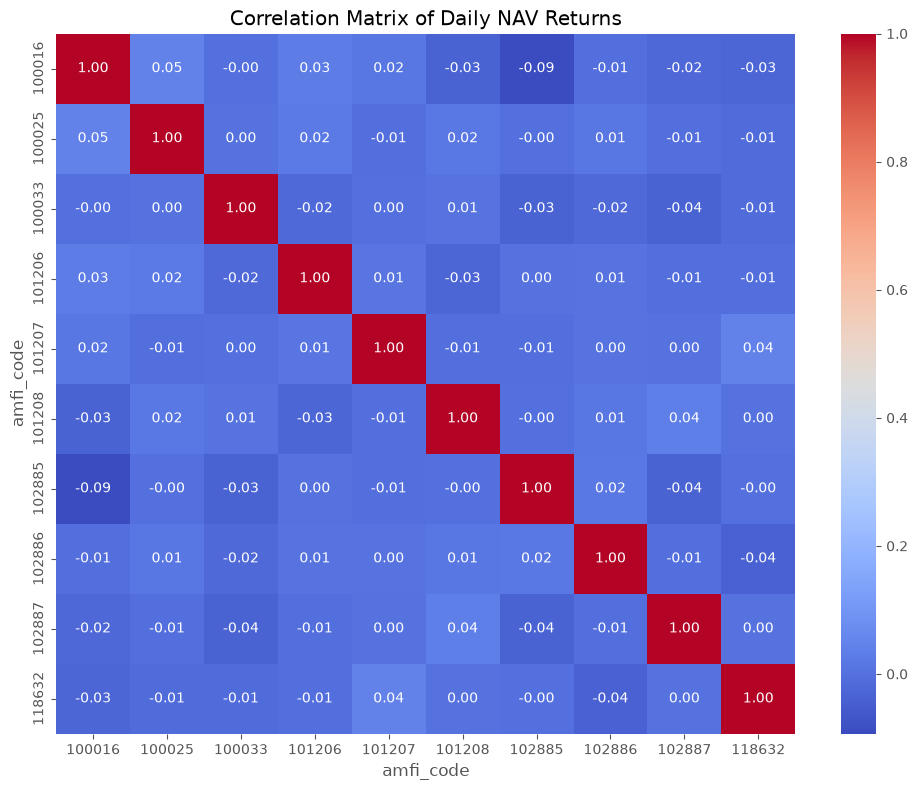

In [31]:
# Calculate daily returns
nav_sorted = nav.sort_values(["amfi_code", "date"]).copy()

nav_sorted["daily_return"] = nav_sorted.groupby("amfi_code")["nav"].pct_change()

pivot_returns = nav_sorted.pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

# Select first 10 funds
corr = pivot_returns.iloc[:, :10].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.tight_layout()

plt.savefig("charts/nav_correlation_heatmap.png", dpi=300)

plt.show()

In [32]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


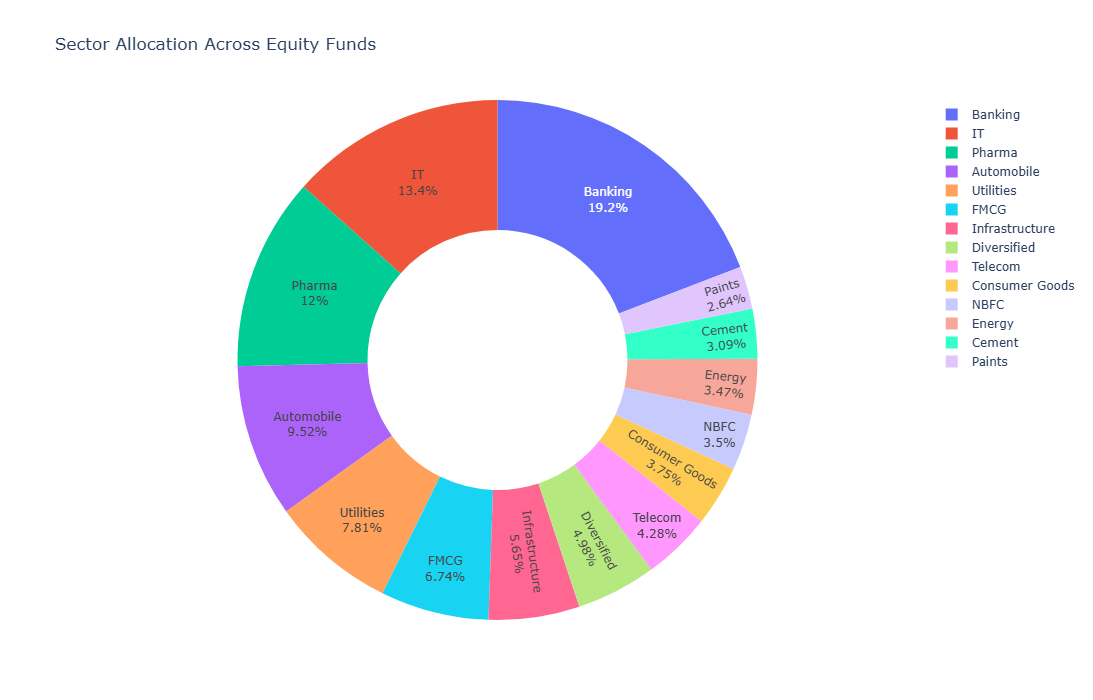

In [33]:
sector_data = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

fig = px.pie(
    names=sector_data.index,
    values=sector_data.values,
    hole=0.5,
    title="Sector Allocation Across Equity Funds"
)

fig.update_traces(textposition="inside", textinfo="percent+label")

fig.update_layout(
    width=900,
    height=700
)

fig.show()

## Insight 10
Portfolio allocation was diversified across multiple sectors, with Banking, Utilities, Pharma, and diversified holdings contributing significantly to overall portfolio weight.

In [34]:
fig.write_image("charts/sector_allocation_donut.png")

In [35]:
import os
print(os.path.exists("charts/sector_allocation_donut.png"))

True


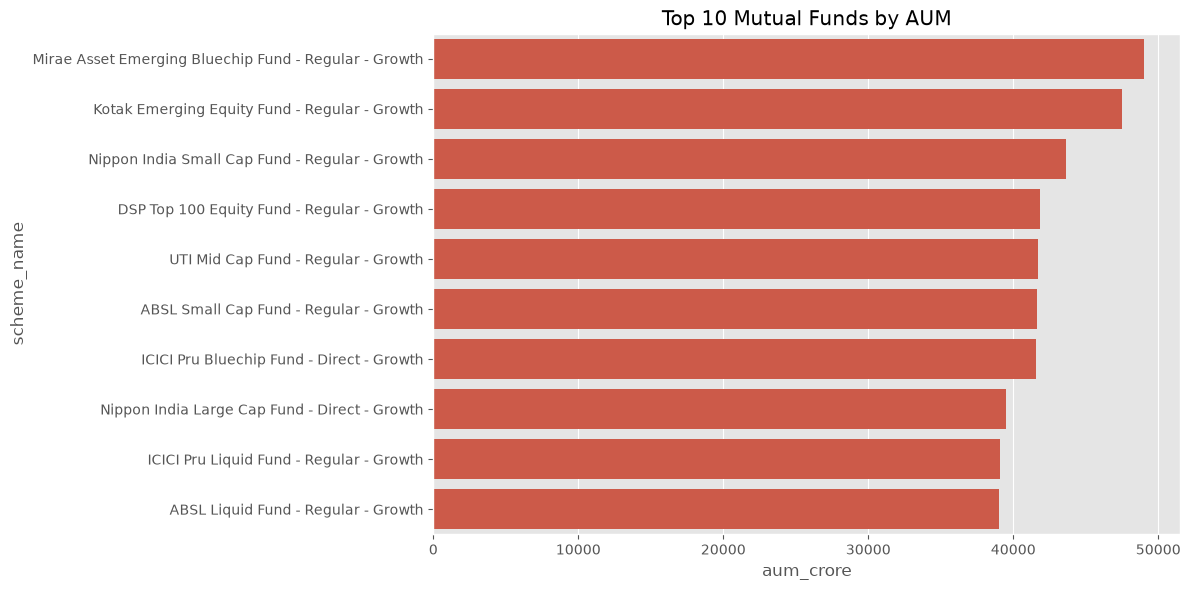

In [36]:
top10 = performance.sort_values(
    "aum_crore",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds by AUM")

plt.tight_layout()

plt.savefig("charts/top10_aum.png", dpi=300)

plt.show()

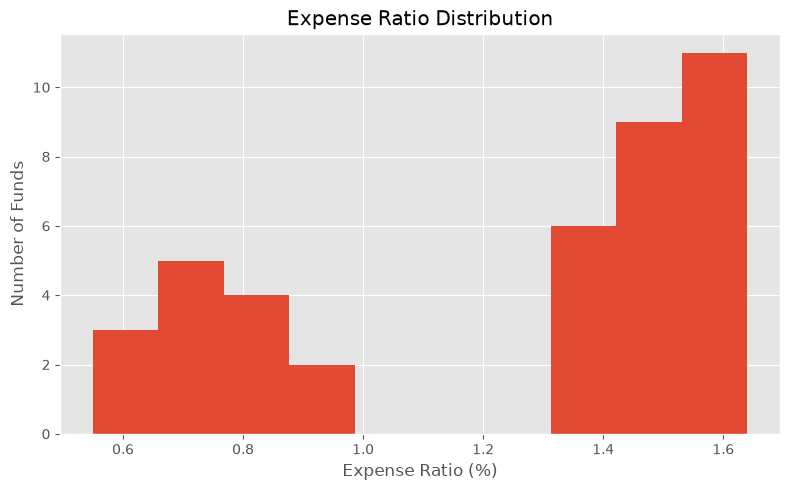

In [37]:
plt.figure(figsize=(8,5))

plt.hist(
    performance["expense_ratio_pct"],
    bins=10
)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Funds")

plt.tight_layout()

plt.savefig("charts/expense_ratio_distribution.png", dpi=300)

plt.show()

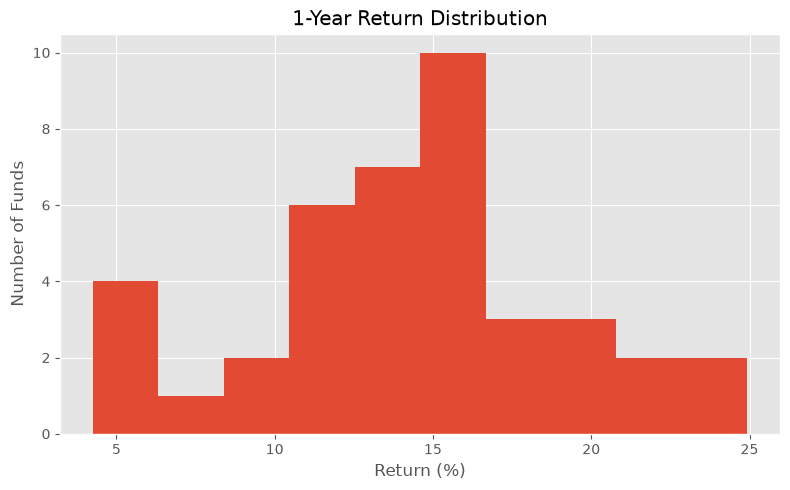

In [38]:
plt.figure(figsize=(8,5))

plt.hist(
    performance["return_1yr_pct"],
    bins=10
)

plt.title("1-Year Return Distribution")
plt.xlabel("Return (%)")
plt.ylabel("Number of Funds")

plt.tight_layout()

plt.savefig("charts/return_distribution.png", dpi=300)

plt.show()